In [1]:
import os
os.environ['WANDB_DISABLED'] = 'true'

In [2]:
!pip install setfit umap-learn datasets evaluate "transformers<5.0" matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 54.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [3]:
import setfit
import umap
import datasets
import evaluate

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
# tweet eva
train = datasets.load_dataset("tweet_eval", 'emotion', split="train")
validation = datasets.load_dataset("tweet_eval", 'emotion', split="validation")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

emotion/train-00000-of-00001.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

emotion/test-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

emotion/validation-00000-of-00001.parque(…):   0%|          | 0.00/28.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3257 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1421 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/374 [00:00<?, ? examples/s]

In [ ]:
train_args = setfit.TrainingArguments(
    num_epochs=3,
    body_learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    logging_dir="logs",
    logging_strategy="epoch",
    logging_steps=10,
    max_steps=1000
)

# initialize clean model with train args
embedding_model = "sentence-transformers/all-MiniLM-L6-v2"
model = setfit.SetFitModel.from_pretrained(embedding_model, train_args=train_args)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import evaluate

In [ ]:
import evaluate
from setfit import SetFitModel, SetFitTrainer

accuracy = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    # eval_pred.predictions and eval_pred.label_ids are typical HF patterns
    y_pred = eval_pred.predictions
    y_true = eval_pred.label_ids
    return accuracy.compute(predictions=y_pred, references=y_true)

model = SetFitModel.from_pretrained(
    "sentence-transformers/all-MiniLM-L6-v2",
)
trainer = setfit.Trainer(
    model=model,
    args=train_args,
    train_dataset=train,
    eval_dataset=validation,
    metric=lambda y_pred, y_true: accuracy.compute(predictions=y_pred, references=y_true),
    column_mapping={"text": "text", "label": "label"},
)

trainer.train()
metrics = trainer.evaluate()
print(metrics)

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-a

Map:   0%|          | 0/3257 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
***** Running training *****
  Num unique pairs = 16000
  Batch size = 16
  Num epochs = 3
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memo

Epoch,Training Loss,Validation Loss
1,0.168900,0.154818


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Deprecati

{'accuracy': 0.8021390374331551}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# generate syntehtic data
from datasets import Dataset
from setfit import get_templated_dataset

# Define your classes
candidate_labels = ["negative", "positive"]

# Create an empty dummy dataset
dummy_dataset = Dataset.from_dict({})

# Generate the synthetic dataset
train_dataset = get_templated_dataset(
    dummy_dataset,
    candidate_labels=candidate_labels,
    template="This text has a {} sentiment.",
    sample_size=8
)

train_dataset['text']

Column(['This text has a negative sentiment.', 'This text has a negative sentiment.', 'This text has a negative sentiment.', 'This text has a negative sentiment.', 'This text has a negative sentiment.', ...])

In [ ]:

# Define parameters
lrs = [1e-3, 1e-9, 2e-5] # 2e-5 is the typical default
epochs_list = [1, 3, 5]

results = []

for lr, ep in zip(lrs, epochs_list):
    print(f"Testing: {params}")

    # Initialize model
    model = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

    # Define arguments
    args = setfit.TrainingArguments(
        body_learning_rate=lr,
        num_epochs=ep,
        max_steps=1000
    )

    # Initialize trainer
    trainer = setfit.Trainer(
        model=model,
        args=args,
        train_dataset=train,
        eval_dataset=validation,
        column_mapping={"text": "text", "label": "label"}
    )

    # Train and evaluate
    trainer.train()
    metrics = trainer.evaluate()

    results.append({
        'params': params,
        'accuracy': metrics.get('accuracy')
    })
    print(f"Accuracy: {metrics.get('accuracy')}")

# Display summary
display(results)

Testing: learning_rate


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to n

Step,Training Loss
1,0.547700
50,0.241900
100,0.261100
150,0.294900
200,0.353100
250,0.343200
300,0.331700
350,0.392700
400,0.389800
450,0.443300


/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Deprecati

Accuracy: 0.42780748663101603
Testing: learning_rate


...

Step,Training Loss
1,0.547700
50,0.339000
100,0.246500
150,0.237200
200,0.207100
250,0.178400
300,0.181800
350,0.168900
400,0.160800
450,0.154700


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57

Accuracy: 0.8021390374331551


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[{'params': 'learning_rate', 'accuracy': 0.42780748663101603},
 {'params': 'learning_rate', 'accuracy': 0.713903743315508},
 {'params': 'learning_rate', 'accuracy': 0.8021390374331551}]

In [ ]:
import pandas as pd
from itertools import product

# Define a more refined grid for performance tuning
param_grid = {
    'learning_rate': [2e-5, 3e-5, 5e-5],
    'num_epochs': [3, 5],
    'batch_size': [16, 32]
}

# We use the Stratified 100 dataset as it performed best in baseline
tuning_train_ds = stratified_train_ds
tuning_results = []

# Iterate through the grid
for lr, epochs, bs in product(param_grid['learning_rate'], param_grid['num_epochs'], param_grid['batch_size']):
    print(f"\n>>> Tuning: LR={lr}, Epochs={epochs}, BatchSize={bs}")

    model_tmp = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

    args_tmp = setfit.TrainingArguments(
        body_learning_rate=lr,
        num_epochs=epochs,
        batch_size=bs,
        max_steps=1000
    )

    trainer_tmp = setfit.Trainer(
        model=model_tmp,
        args=args_tmp,
        train_dataset=tuning_train_ds,
        eval_dataset=validation,
        column_mapping={"text": "text", "label": "label"}
    )

    trainer_tmp.train()
    metrics_tmp = trainer_tmp.evaluate()

    tuning_results.append({
        'lr': lr,
        'epochs': epochs,
        'batch_size': bs,
        'accuracy': metrics_tmp.get('accuracy')
    })

# Convert to DataFrame and find best params
tuning_df = pd.DataFrame(tuning_results)
best_params = tuning_df.loc[tuning_df['accuracy'].idxmax()]

print("\n--- Hyperparameter Tuning Complete ---")
print(f"Best Accuracy: {best_params['accuracy']:.4f}")
print(f"Optimal Params: LR={best_params['lr']}, Epochs={best_params['epochs']}, BS={best_params['batch_size']}")

display(tuning_df.sort_values(by='accuracy', ascending=False))



>>> Tuning: LR=2e-05, Epochs=3, BatchSize=16


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to n

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 6910
  Batch size = 16
  Num epochs = 3
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


Step,Training Loss
1,0.530600
50,0.304300
100,0.222300
150,0.148300
200,0.069700
250,0.025800
300,0.008300
350,0.006000
400,0.003500
450,0.003100


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Deprecati


--- Hyperparameter Tuning Complete ---
Best Accuracy: 0.6979
Optimal Params: LR=2e-05, Epochs=3.0, BS=16.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,lr,epochs,batch_size,accuracy
0,0.00002,3,16,0.697861
2,0.00002,5,16,0.697861
6,0.00003,5,16,0.697861
4,0.00003,3,16,0.697861
3,0.00002,5,32,0.689840
1,0.00002,3,32,0.689840
10,0.00005,5,16,0.689840
8,0.00005,3,16,0.689840
7,0.00003,5,32,0.687166
5,0.00003,3,32,0.687166


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import os
import torch
import evaluate
import matplotlib.pyplot as plt
from setfit import SetFitModel, Trainer, TrainingArguments

# Load accuracy metric
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(y_pred, y_test):
    return accuracy_metric.compute(predictions=y_pred, references=y_test)

# 1. Define Training Arguments with logging and evaluation enabled
args = TrainingArguments(
    num_epochs=5,
    batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=5,
    output_dir="./checkpoints"
)

# Initialize a fresh model
model = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

# 2. Initialize Trainer with metric function
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=stratified_train_ds,
    eval_dataset=validation,
    metric=compute_metrics,
    column_mapping={"text": "text", "label": "label"}
)

# 3. Train the model (logs will now include eval_accuracy)
trainer.train()

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to n

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 6910
  Batch size = 16
  Num epochs = 5
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


Epoch,Training Loss,Validation Loss
1,0.119700,0.207295
2,0.001500,0.211422
3,0.000600,0.214137
4,0.000400,0.216200
5,0.000300,0.216945


/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57

Available metrics in logs: ['embedding_loss', 'epoch', 'grad_norm', 'learning_rate', 'step', 'eval_embedding_loss', 'eval_embedding_runtime', 'eval_embedding_samples_per_second', 'eval_embedding_steps_per_second']


/tmp/ipykernel_1933/4021867054.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


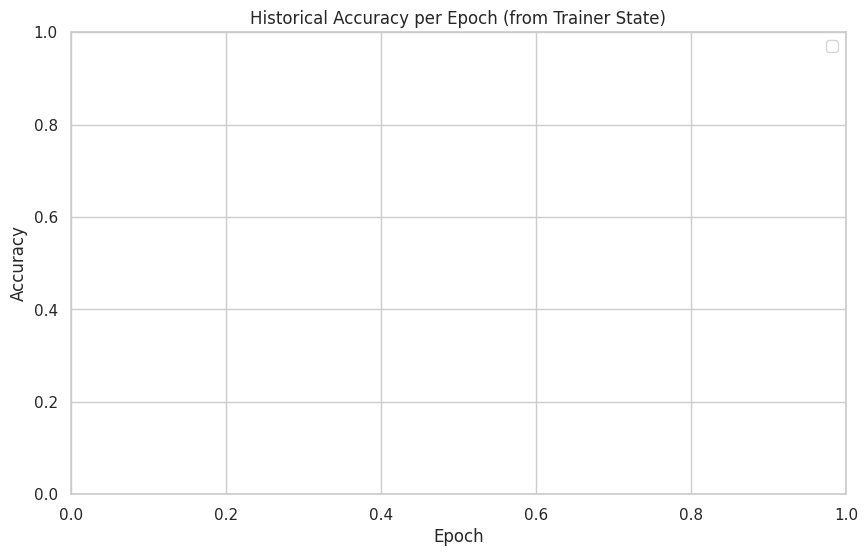

,epoch
0,0.002315
1,1.000000
2,1.000000
3,2.000000
4,2.000000
5,3.000000
6,3.000000
7,4.000000
8,4.000000
9,5.000000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

# 4. Extract metrics from trainer_state.json in the checkpoints
checkpoint_dirs = sorted([d for d in os.listdir("./checkpoints") if d.startswith("checkpoint-")], key=lambda x: int(x.split("-")[1]))

metrics_history = []

if checkpoint_dirs:
    latest_ckpt = checkpoint_dirs[-1]
    state_path = os.path.join("./checkpoints", latest_ckpt, "trainer_state.json")

    if os.path.exists(state_path):
        with open(state_path, "r") as f:
            state_data = json.load(f)
            metrics_history = state_data.get("log_history", [])

if metrics_history:
    df_history = pd.DataFrame(metrics_history)

    # Identify columns present in the logs
    available_cols = df_history.columns.tolist()
    print(f"Available metrics in logs: {available_cols}")

    # 5. Filter and Plot the results
    # We look for evaluation metrics (usually labeled with 'eval_')
    eval_metrics = [c for c in available_cols if c.startswith('eval_') and 'accuracy' in c]
    train_metrics = [c for c in available_cols if not c.startswith('eval_') and 'accuracy' in c]

    plt.figure(figsize=(10, 6))

    # Plot Evaluation Accuracy if exists
    for col in eval_metrics:
        eval_df = df_history.dropna(subset=[col])
        if not eval_df.empty:
            plt.plot(eval_df['epoch'], eval_df[col], label=f'Validation {col}', marker='o')

    # Plot Training Accuracy if exists
    for col in train_metrics:
        train_df = df_history.dropna(subset=[col])
        if not train_df.empty:
            plt.plot(train_df['epoch'], train_df[col], label=f'Training {col}', marker='x', linestyle='--')

    plt.title("Historical Accuracy per Epoch (from Trainer State)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Display exact accuracy table
    accuracy_df = df_history.dropna(subset=eval_metrics + train_metrics)
    if not accuracy_df.empty:
        display(accuracy_df[['epoch'] + eval_metrics + train_metrics])
    else:
        print("No accuracy metrics found in logs.")
else:
    print("No log history found in checkpoints.")

In [ ]:
df_history

,embedding_loss,epoch,grad_norm,learning_rate,step,eval_embedding_loss,eval_embedding_runtime,eval_embedding_samples_per_second,eval_embedding_steps_per_second
0,0.5306,0.002315,2.830308,0.000000e+00,1,NaN,NaN,NaN,NaN
1,0.1197,1.000000,0.226932,1.778807e-05,432,NaN,NaN,NaN,NaN
2,NaN,1.000000,NaN,NaN,432,0.207295,107.1044,897.834,56.123
3,0.0015,2.000000,0.029805,1.334362e-05,864,NaN,NaN,NaN,NaN
4,NaN,2.000000,NaN,NaN,864,0.211422,106.2351,905.181,56.582
5,0.0006,3.000000,0.025867,8.899177e-06,1296,NaN,NaN,NaN,NaN
6,NaN,3.000000,NaN,NaN,1296,0.214137,107.2142,896.915,56.065
7,0.0004,4.000000,0.022439,4.454733e-06,1728,NaN,NaN,NaN,NaN
8,NaN,4.000000,NaN,NaN,1728,0.216200,109.9566,874.545,54.667
9,0.0003,5.000000,0.041697,1.028807e-08,2160,NaN,NaN,NaN,NaN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Visualizing Model Interpretability with UMAP
We will extract the embeddings for the validation set and use UMAP to visualize how the model clusters the different emotion classes.

In [ ]:
import umap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Extract embeddings from the model
# SetFitModel.model_body is the underlying sentence transformer
print("Extracting embeddings...")
embeddings = model.model_body.encode(validation['text'])
labels = np.array(validation['label'])
label_names = validation.features['label'].names

# 2. Use UMAP for dimensionality reduction
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

# 3. Visualize the clusters
plt.figure(figsize=(12, 8))
for i, name in enumerate(label_names):
    mask = labels == i
    plt.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1], label=name, alpha=0.6, s=10)

plt.legend()
plt.title("UMAP Projection of TweetEval Emotion Embeddings")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
import torch

gpu_available = torch.cuda.is_available()
print(f"Is GPU available: {gpu_available}")
if gpu_available:
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("Currently using CPU. Follow the instructions in the chat to enable GPU.")

Is GPU available: False
Currently using CPU. Follow the instructions in the chat to enable GPU.


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# --- Approach 1: Stratified 100 examples ---
train_df = train.to_pandas()
stratified_df, _ = train_test_split(
    train_df,
    train_size=100,
    stratify=train_df['label'],
    random_state=42
)
stratified_train_ds = datasets.Dataset.from_pandas(stratified_df, preserve_index=False)
print(f"Approach 1 Dataset Size: {len(stratified_train_ds)}")

Approach 1 Dataset Size: 100


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

# --- Approach 2: Cluster-based Representative Sampling (20 examples) ---
print("Embedding training set for clustering...")
train_embeddings = model.model_body.encode(train['text'])

# Cluster into 20 groups
n_clusters = 20
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto').fit(train_embeddings)

# Find the index of the closest example to each cluster center
closest_indices, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, train_embeddings)

cluster_train_ds = train.select(closest_indices)
print(f"Approach 2 Dataset Size: {len(cluster_train_ds)}")
print("Sample representative texts:")
display(cluster_train_ds['text'][:5])

Embedding training set for clustering...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Approach 2 Dataset Size: 20
Sample representative texts:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


["@user wow I'm just really sadden by that. Terrible",
 "@user spent over 2 fucking hours and still can't get that dam SIVA fragment on Fellwinters peak mountain #angry",
 "Mate the thing I get excited about in my profession are mad. A client said she opened her bowels, I'm rejoicing",
 'Watch this amazing live.ly broadcast by @user #lively #musically',
 'Boys of Fall makes me miss cheering on Friday nights much sooooo bad #bulldogslways🐾']

In [ ]:

# Define the training datasets to compare
experiments = [
    ("Stratified Sampling (100 samples)", stratified_train_ds),
    ("Cluster-based Sampling (20 samples)", cluster_train_ds)
]

comparison_results = []

for name, train_ds in experiments:
    print(f"\n--- Training: {name} ---")

    # Initialize a fresh model for each run
    model = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

    # Initialize trainer
    trainer = setfit.Trainer(
        model=model,
        train_dataset=train_ds,
        eval_dataset=validation,
        column_mapping={"text": "text", "label": "label"}
    )

    # Train and Evaluate
    trainer.train()
    metrics = trainer.evaluate()

    comparison_results.append({"Method": name, "Accuracy": metrics.get("accuracy")})

# Display final comparison
import pandas as pd
results_df = pd.DataFrame(comparison_results)
display(results_df)



--- Training: Stratified Sampling (100 samples) ---


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to n

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 6910
  Batch size = 16
  Num epochs = 1
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


Step,Training Loss
1,0.530600
50,0.280500
100,0.199900
150,0.110300
200,0.055200
250,0.025900
300,0.012100
350,0.010000
400,0.007000


...

***** Running training *****
  Num unique pairs = 282
  Batch size = 16
  Num epochs = 1
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


Step,Training Loss
1,0.265700


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
***** Running evaluation *****
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Dep

,Method,Accuracy
0,Stratified Sampling (100 samples),0.700535
1,Cluster-based Sampling (20 samples),0.497326


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

# --- Approach 3: Cluster-based Sampling with 50 clusters ---
print("Embedding training set for 50-cluster sampling...")
train_embeddings_50 = model.model_body.encode(train['text'])

n_clusters_50 = 50
kmeans_50 = KMeans(n_clusters=n_clusters_50, random_state=42, n_init='auto').fit(train_embeddings_50)
closest_indices_50, _ = pairwise_distances_argmin_min(kmeans_50.cluster_centers_, train_embeddings_50)
cluster_train_ds_50 = train.select(closest_indices_50)

print(f"New Dataset Size: {len(cluster_train_ds_50)}")

# Initialize and train fresh model
model_50 = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
trainer_50 = setfit.Trainer(
    model=model_50,
    train_dataset=cluster_train_ds_50,
    eval_dataset=validation,
    column_mapping={"text": "text", "label": "label"}
)

trainer_50.train()
metrics_50 = trainer_50.evaluate()

print(f"Accuracy with 50 clusters: {metrics_50.get('accuracy')}")

# Update results table
new_result = {"Method": "Cluster-based (50 samples)", "Accuracy": metrics_50.get("accuracy")}
results_df = pd.concat([results_df, pd.DataFrame([new_result])], ignore_index=True)
display(results_df)

Embedding training set for 50-cluster sampling...
New Dataset Size: 75


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (fo

Map:   0%|          | 0/75 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 3596
  Batch size = 16
  Num epochs = 1
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


Step,Training Loss
1,0.465600
50,0.250400
100,0.167100
150,0.078800
200,0.041700


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
***** Running evaluation *****
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Accuracy with 50 clusters: 0.6229946524064172


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Method,Accuracy
0,Stratified Sampling (100 samples),0.700535
1,Cluster-based Sampling (20 samples),0.497326
2,Cluster-based (50 samples),0.657754
3,Cluster-based (50 samples),0.622995


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

# --- Approach 3: Cluster-based Sampling with 50 clusters ---
print("Embedding training set for 50-cluster sampling...")
train_embeddings_50 = model.model_body.encode(train['text'])

n_clusters_50 = 50
kmeans_50 = KMeans(n_clusters=n_clusters_50, random_state=42, n_init='auto').fit(train_embeddings_50)
closest_indices_50, _ = pairwise_distances_argmin_min(kmeans_50.cluster_centers_, train_embeddings_50)
cluster_train_ds_50 = train.select(closest_indices_50)

print(f"New Dataset Size: {len(cluster_train_ds_50)}")

# Initialize and train fresh model
model_50 = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
trainer_50 = setfit.Trainer(
    model=model_50,
    train_dataset=cluster_train_ds_50,
    eval_dataset=validation,
    column_mapping={"text": "text", "label": "label"}
)

trainer_50.train()
metrics_50 = trainer_50.evaluate()

print(f"Accuracy with 50 clusters: {metrics_50.get('accuracy')}")

# Update results table
new_result = {"Method": "Cluster-based (50 samples)", "Accuracy": metrics_50.get("accuracy")}
results_df = pd.concat([results_df, pd.DataFrame([new_result])], ignore_index=True)
display(results_df)

In [ ]:

# --- Approach 4: Cluster-based Sampling with 100 clusters ---
print("Embedding training set for 100-cluster sampling...")
n_clusters_100 = 100
kmeans_100 = KMeans(n_clusters=n_clusters_100, random_state=42, n_init='auto').fit(train_embeddings)
closest_indices_100, _ = pairwise_distances_argmin_min(kmeans_100.cluster_centers_, train_embeddings)
cluster_train_ds_100 = train.select(closest_indices_100)

# Initialize and train fresh model
model_100 = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
trainer_100 = setfit.Trainer(
    model=model_100,
    train_dataset=cluster_train_ds_100,
    eval_dataset=validation,
    column_mapping={"text": "text", "label": "label"}
)

trainer_100.train()
metrics_100 = trainer_100.evaluate()

# Update results table
new_result_100 = {"Method": "Cluster-based (100 samples)", "Accuracy": metrics_100.get("accuracy")}
results_df = pd.concat([results_df, pd.DataFrame([new_result_100])], ignore_index=True)
print(f"Accuracy with 100 clusters: {metrics_100.get('accuracy')}")


Embedding training set for 100-cluster sampling...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (fo

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 7338
  Batch size = 16
  Num epochs = 1
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


Step,Training Loss
1,0.587600
50,0.272300
100,0.225500
150,0.198200
200,0.144600
250,0.073700
300,0.026300
350,0.014400
400,0.010100
450,0.008900


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
***** Running evaluation *****
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Accuracy with 100 clusters: 0.6737967914438503


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:

# --- Approach 5: Stratified 20 examples ---
stratified_df_20, _ = train_test_split(
    train_df,
    train_size=20,
    stratify=train_df['label'],
    random_state=42
)
stratified_train_ds_20 = datasets.Dataset.from_pandas(stratified_df_20, preserve_index=False)

# Initialize and train fresh model
model_strat_20 = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
trainer_strat_20 = setfit.Trainer(
    model=model_strat_20,
    train_dataset=stratified_train_ds_20,
    eval_dataset=validation,
    column_mapping={"text": "text", "label": "label"}
)

trainer_strat_20.train()
metrics_strat_20 = trainer_strat_20.evaluate()

# Update results table
new_result_strat_20 = {"Method": "Stratified (20 samples)", "Accuracy": metrics_strat_20.get("accuracy")}
results_df = pd.concat([results_df, pd.DataFrame([new_result_strat_20])], ignore_index=True)

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to n

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 274
  Batch size = 16
  Num epochs = 1
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


Step,Training Loss
1,0.360100


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
***** Running evaluation *****
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


NameError: name 'plt' is not defined

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
import pandas as pd
import numpy as np
from datasets import Dataset

# 1. Prepare data
train_df = train.to_pandas()
unique_labels = train_df['label'].unique()
all_selected_indices = []

print(f"Starting stratified clustering for {len(unique_labels)} categories...")

# 2. Iterate through each category
for label in unique_labels:
    # Filter data for current category
    category_df = train_df[train_df['label'] == label]
    category_indices = category_df.index.tolist()

    # Get embeddings for this specific category
    print(f"- Processing category {label} ({len(category_df)} samples)")
    category_embeddings = model.model_body.encode(category_df['text'].tolist())

    # 3. Train KMeans for 25 clusters in this category
    n_clusters = min(25, len(category_df))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto').fit(category_embeddings)

    # 4. Find the most representative sample for each cluster (closest to centroid)
    # These indices are relative to the category_embeddings array
    closest_rel_indices, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, category_embeddings)

    # Map relative indices back to original train_df indices
    selected_original_indices = [category_indices[i] for i in closest_rel_indices]
    all_selected_indices.extend(selected_original_indices)

# 5. Create the new training dataset
strat_cluster_train_ds = train.select(all_selected_indices)
print(f"\nFinal Dataset Size: {len(strat_cluster_train_ds)} ({len(unique_labels)} categories x 25 samples)")

# 6. Initialize and train a fresh model for this experiment
print("Training SetFit model on stratified-cluster data...")
model_strat_cluster = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

trainer_strat_cluster = setfit.Trainer(
    model=model_strat_cluster,
    train_dataset=strat_cluster_train_ds,
    eval_dataset=validation,
    column_mapping={"text": "text", "label": "label"}
)

trainer_strat_cluster.train()
metrics_sc = trainer_strat_cluster.evaluate()

# Update comparison results
new_result_sc = {"Method": "Stratified + 25 Clusters/Cat", "Accuracy": metrics_sc.get("accuracy")}
results_df = pd.concat([results_df, pd.DataFrame([new_result_sc])], ignore_index=True)

print(f"\nExperiment Accuracy: {metrics_sc.get('accuracy'):.4f}")
display(results_df)

Starting stratified clustering for 4 categories...
- Processing category 2 (294 samples)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


- Processing category 0 (1400 samples)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


- Processing category 1 (708 samples)


...

Step,Training Loss
1,0.457200
50,0.270300
100,0.232400
150,0.202900
200,0.149000
250,0.078300
300,0.047300
350,0.022700
400,0.013500
450,0.011300


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Deprecati


Experiment Accuracy: 0.6150


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Method,Accuracy
0,Stratified Sampling (100 samples),0.700535
1,Cluster-based Sampling (20 samples),0.497326
2,Cluster-based (50 samples),0.657754
3,Cluster-based (100 samples),0.673797
4,Stratified (20 samples),0.462567
5,Stratified + 25 Clusters/Cat,0.614973


/tmp/ipykernel_1933/982005614.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Method", y="Accuracy", data=results_df, palette="viridis")
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


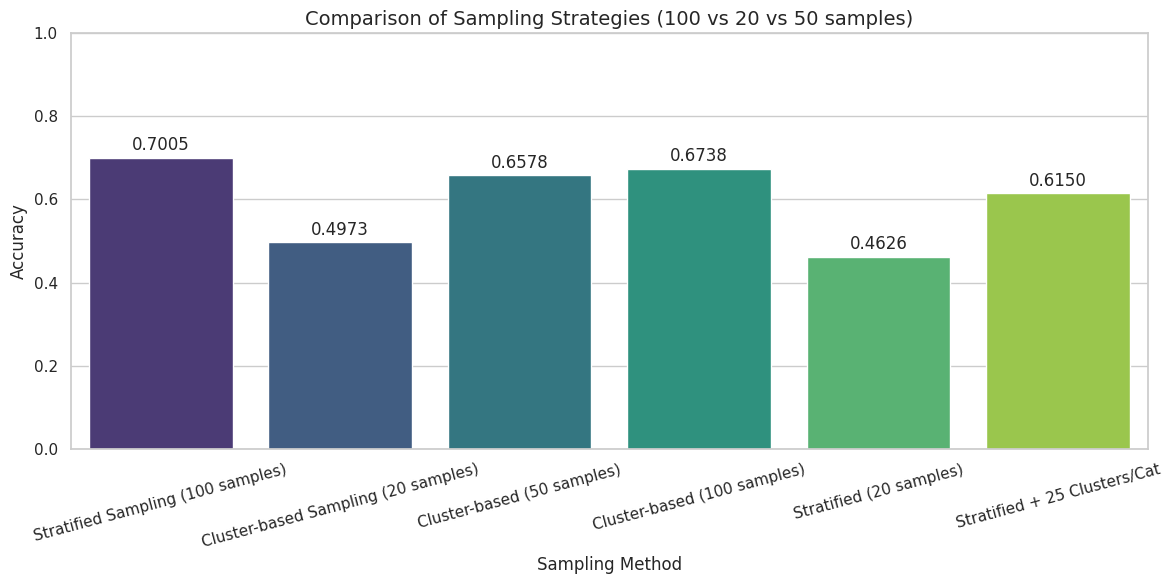

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a bar plot for accuracy comparison including the 50-cluster results
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x="Method", y="Accuracy", data=results_df, palette="viridis")

# Add labels and title
plt.title("Comparison of Sampling Strategies (100 vs 20 vs 50 samples)", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)
plt.xlabel("Sampling Method", fontsize=12)
plt.ylim(0, 1.0)

# Annotate bars with accuracy values for clear comparison
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Prepare text data for sklearn
train_texts = train['text']
train_labels = train['label']
val_texts = validation['text']
val_labels = validation['label']

# 2. TF-IDF Vectorization (High-dimensional Bag-of-Words)
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)

# 3. Implement the Wide MLP Blueprint
# Width: 1024 units, Layer: 1, Optimizer: Adam, Batch Size: 16
mlp = MLPClassifier(
    hidden_layer_sizes=(1024,),
    activation='relu',
    solver='adam',
    batch_size=16,
    learning_rate_init=1e-3,
    max_iter=100,
    random_state=42,
    verbose=True
)

# 4. Train and Predict
print("Training Wide MLP...")
mlp.fit(X_train, train_labels)

y_pred = mlp.predict(X_val)

# 5. Evaluate
print("\n--- Wide MLP Performance ---")
print(f"Accuracy: {accuracy_score(val_labels, y_pred):.4f}")
print(classification_report(val_labels, y_pred, target_names=label_names))

Training Wide MLP...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Iteration 1, loss = 1.04950969

--- Wide MLP Performance ---
Accuracy: 0.6578


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


NameError: name 'label_names' is not defined

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import re
import os

# 1. Improved Preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r"(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)", " ", text)
    return text

vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    stop_words='english',
    preprocessor=clean_text
)

X_train = vectorizer.fit_transform(train['text'])
X_val = vectorizer.transform(validation['text'])

# 2. Setup Data
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train_t = torch.tensor(X_train.toarray(), dtype=torch.float32)
y_train_t = torch.tensor(train['label'], dtype=torch.long)
X_val_t = torch.tensor(X_val.toarray(), dtype=torch.float32)
y_val_t = torch.tensor(validation['label'], dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=16)

# 3. Model with slightly higher Dropout for regularization
model_pt = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(X_train.shape[1], 1024),
    nn.ReLU(),
    nn.Dropout(0.6),
    nn.Linear(1024, 4)
).to(device)

optimizer = optim.Adam(model_pt.parameters(), lr=1e-4) # Lowered LR
criterion = nn.CrossEntropyLoss()

# 4. Training with Intra-Epoch Logging and Periodic Saving
print(f"Starting training on {device}...")
for epoch in range(50):
    model_pt.train()
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_pt(inputs), labels)
        loss.backward()
        optimizer.step()

        # Break down the first epoch specifically
        if epoch == 0 and i % 50 == 0:
            model_pt.eval()
            with torch.no_grad():
                v_loss = sum(criterion(model_pt(vx.to(device)), vy.to(device)).item() for vx, vy in val_loader) / len(val_loader)
            print(f"Epoch 1, Step {i}: Train Loss {loss.item():.4f}, Val Loss {v_loss:.4f}")
            model_pt.train()

    # Standard epoch logging
    model_pt.eval()
    with torch.no_grad():
        epoch_v_loss = sum(criterion(model_pt(vx.to(device)), vy.to(device)).item() for vx, vy in val_loader) / len(val_loader)
    print(f">>> End Epoch {epoch+1}: Val Loss {epoch_v_loss:.4f}")

    # Save model every 5 epochs
    if (epoch + 1) % 5 == 0:
        save_path = f"model_pt_epoch_{epoch+1}.pth"
        torch.save(model_pt.state_dict(), save_path)
        print(f"[Checkpoint] Saved model to {save_path}")

Starting training on cuda...
Epoch 1, Step 0: Train Loss 1.3926, Val Loss 1.3836
Epoch 1, Step 50: Train Loss 1.3579, Val Loss 1.3697
Epoch 1, Step 100: Train Loss 1.3683, Val Loss 1.3545
Epoch 1, Step 150: Train Loss 1.3319, Val Loss 1.3381
Epoch 1, Step 200: Train Loss 1.2810, Val Loss 1.3183
>>> End Epoch 1: Val Loss 1.3174
>>> End Epoch 2: Val Loss 1.2475
>>> End Epoch 3: Val Loss 1.2167
>>> End Epoch 4: Val Loss 1.1904
>>> End Epoch 5: Val Loss 1.1569
[Checkpoint] Saved model to model_pt_epoch_5.pth
>>> End Epoch 6: Val Loss 1.1150
>>> End Epoch 7: Val Loss 1.0704
>>> End Epoch 8: Val Loss 1.0281
>>> End Epoch 9: Val Loss 0.9909
>>> End Epoch 10: Val Loss 0.9592
[Checkpoint] Saved model to model_pt_epoch_10.pth
>>> End Epoch 11: Val Loss 0.9341
>>> End Epoch 12: Val Loss 0.9127
>>> End Epoch 13: Val Loss 0.8981
>>> End Epoch 14: Val Loss 0.8859
>>> End Epoch 15: Val Loss 0.8769
[Checkpoint] Saved model to model_pt_epoch_15.pth
>>> End Epoch 16: Val Loss 0.8652
>>> End Epoch 17: Va

In [ ]:
import torch
import evaluate
import datasets
import os
from torch.utils.data import DataLoader, TensorDataset

# 1. Setup Data Loaders for all splits
def get_loader(dataset_split, vectorizer_obj):
    X = vectorizer_obj.transform(dataset_split['text'])
    X_t = torch.tensor(X.toarray(), dtype=torch.float32)
    y_t = torch.tensor(dataset_split['label'], dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=16)

train_eval_loader = get_loader(train, vectorizer)
val_eval_loader = get_loader(validation, vectorizer)
test_ds = datasets.load_dataset("tweet_eval", "emotion", split="test")
test_loader = get_loader(test_ds, vectorizer)

# 2. Evaluation Function
def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = evaluate.load("accuracy")
    return accuracy.compute(predictions=all_preds, references=all_labels)

# 3. Load Epoch 15 and Evaluate all splits
checkpoint_path = "model_pt_epoch_20.pth"
if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint: {checkpoint_path}")
    model_pt.load_state_dict(torch.load(checkpoint_path, map_location=device))

    print("Evaluating Wide MLP (Epoch 15) across all splits...")
    train_metrics = evaluate_model(model_pt, train_eval_loader)
    val_metrics = evaluate_model(model_pt, val_eval_loader)
    test_metrics = evaluate_model(model_pt, test_loader)

    print(f"\nTrain Accuracy: {train_metrics['accuracy']:.4f}")
    print(f"Validation Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Test Accuracy: {test_metrics['accuracy']:.4f}")
else:
    print(f"Error: {checkpoint_path} not found.")

Loading checkpoint: model_pt_epoch_20.pth
Evaluating Wide MLP (Epoch 15) across all splits...

Train Accuracy: 0.8932
Validation Accuracy: 0.6631
Test Accuracy: 0.6721


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize and Train SVM
# We use the X_train/X_val features generated by the TfidfVectorizer in cell 7bf2be99
print("Training SVM Classifier (RBF Kernel)...")
svm_clf = SVC(kernel='rbf', C=1.0, random_state=42)
svm_clf.fit(X_train, train['label'])

# 2. Define Evaluation Helper
def eval_sklearn_model(model, X, y, split_name):
    preds = model.predict(X)
    acc = accuracy_score(y, preds)
    print(f"{split_name} Accuracy: {acc:.4f}")
    return acc

# 3. Evaluate on all splits
print("--- SVM Performance Metrics ---")
eval_sklearn_model(svm_clf, X_train, train['label'], "Train")
eval_sklearn_model(svm_clf, X_val, validation['label'], "Validation")

# Preprocess test set for SVM
X_test = vectorizer.transform(test_ds['text'])
eval_sklearn_model(svm_clf, X_test, test_ds['label'], "Test")

# Print detailed report for Test set
test_preds = svm_clf.predict(X_test)
print("\nDetailed Test Classification Report:")
print(classification_report(test_ds['label'], test_preds, target_names=validation.features['label'].names))

Training SVM Classifier (RBF Kernel)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


--- SVM Performance Metrics ---
Train Accuracy: 0.9598
Validation Accuracy: 0.6444


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Test Accuracy: 0.6517


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Detailed Test Classification Report:
              precision    recall  f1-score   support

       anger       0.59      0.92      0.72       558
         joy       0.76      0.50      0.61       358
    optimism       0.81      0.11      0.19       123
     sadness       0.75      0.57      0.64       382

    accuracy                           0.65      1421
   macro avg       0.73      0.53      0.54      1421
weighted avg       0.69      0.65      0.62      1421



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_extraction.text import TfidfVectorizer
import datasets
import re

# 1. Load AG News Dataset
print("Loading ag_news dataset...")
ag_train = datasets.load_dataset('ag_news', split='train')
ag_test = datasets.load_dataset('ag_news', split='test')

# 2. Preprocessing & Vectorization
def clean_news_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\\s]', ' ', text)
    return text

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    preprocessor=clean_news_text
)

print("Vectorizing text...")
X_train = vectorizer.fit_transform(ag_train['text'])
X_test = vectorizer.transform(ag_test['text'])

# 3. Setup PyTorch Tensors and Loaders
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train_t = torch.tensor(X_train.toarray(), dtype=torch.float32)
y_train_t = torch.tensor(ag_train['label'], dtype=torch.long)
X_test_t = torch.tensor(X_test.toarray(), dtype=torch.float32)
y_test_t = torch.tensor(ag_test['label'], dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32)

# 4. Define Wide MLP Architecture (4 output classes for AG News)
model_ag = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(X_train.shape[1], 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 4)
).to(device)

optimizer = optim.Adam(model_ag.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# 5. Training Loop with Logging
print(f"Starting training on {device}...")
for epoch in range(10):
    model_ag.train()
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_ag(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        if i % 500 == 0:
            print(f"Epoch {epoch+1}, Step {i}: Batch Loss {loss.item():.4f}")

    # Validation check after each epoch
    model_ag.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_ag(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f">>> End Epoch {epoch+1}: Test Accuracy {100 * correct / total:.2f}%")

    # Periodic Save
    if (epoch + 1) % 5 == 0:
        torch.save(model_ag.state_dict(), f'model_ag_news_epoch_{epoch+1}.pth')
        print(f"Checkpoint saved.")

Loading ag_news dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Vectorizing text...
Starting training on cuda...
Epoch 1, Step 0: Batch Loss 1.3903
Epoch 1, Step 500: Batch Loss 1.0957
Epoch 1, Step 1000: Batch Loss 0.7021
Epoch 1, Step 1500: Batch Loss 0.6025
Epoch 1, Step 2000: Batch Loss 0.5006
Epoch 1, Step 2500: Batch Loss 0.6029
Epoch 1, Step 3000: Batch Loss 0.5538
Epoch 1, Step 3500: Batch Loss 0.4141
>>> End Epoch 1: Test Accuracy 89.96%
Epoch 2, Step 0: Batch Loss 0.4490
Epoch 2, Step 500: Batch Loss 0.4087
Epoch 2, Step 1000: Batch Loss 0.3742
Epoch 2, Step 1500: Batch Loss 0.3621
Epoch 2, Step 2000: Batch Loss 0.3118
Epoch 2, Step 2500: Batch Loss 0.4833
Epoch 2, Step 3000: Batch Loss 0.3131
Epoch 2, Step 3500: Batch Loss 0.3291
>>> End Epoch 2: Test Accuracy 90.41%
Epoch 3, Step 0: Batch Loss 0.5233
Epoch 3, Step 500: Batch Loss 0.3908
Epoch 3, Step 1000: Batch Loss 0.3801
Epoch 3, Step 1500: Batch Loss 0.3343
Epoch 3, Step 2000: Batch Loss 0.2758
Epoch 3, Step 2500: Batch Loss 0.2249
Epoch 3, Step 3000: Batch Loss 0.2005
Epoch 3, Step

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from setfit import SetFitModel, Trainer, TrainingArguments
import datasets
import pandas as pd
import numpy as np

# 1. Stratified Sampling (1000 samples)
ag_train_full = datasets.load_dataset('ag_news', split='train')
ag_test = datasets.load_dataset('ag_news', split='test')

train_df = ag_train_full.to_pandas()
strat_df, _ = train_test_split(
    train_df,
    train_size=1000,
    stratify=train_df['label'],
    random_state=42
)
strat_ds = datasets.Dataset.from_pandas(strat_df)

# 2. Train SetFit on 1000 samples with step limit
print("Training SetFit model on 1000 stratified samples (Max Steps: 5000)...")
train_args = TrainingArguments(max_steps=5000)
model_setfit = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
trainer_setfit = Trainer(
    model=model_setfit,
    args=train_args,
    train_dataset=strat_ds,
    column_mapping={"text": "text", "label": "label"}
)
trainer_setfit.train()

# 3. Use SetFit to predict labels for the entire dataset (Pseudo-labeling)
print("Generating pseudo-labels for the full dataset...")
pseudo_labels = model_setfit.predict(ag_train_full['text'])

# 4. Train Torch model on artificial dataset
print("Vectorizing text for Torch model...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_pseudo = vectorizer.fit_transform(ag_train_full['text'])
X_test = vectorizer.transform(ag_test['text'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train_t = torch.tensor(X_train_pseudo.toarray(), dtype=torch.float32)
y_train_t = torch.tensor(pseudo_labels, dtype=torch.long)
X_test_t = torch.tensor(X_test.toarray(), dtype=torch.float32)
y_test_t = torch.tensor(ag_test['label'], dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32)

model_pt = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(5000, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 4)
).to(device)

optimizer = optim.Adam(model_pt.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

print("Training Torch MLP on pseudo-labeled data...")
for epoch in range(5):
    model_pt.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_pt(inputs), labels)
        loss.backward()
        optimizer.step()

# 5. Compute Metrics
model_pt.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_pt(inputs)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Final Accuracy on True Test Labels: {correct/total:.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Training SetFit model on 1000 stratified samples (Max Steps: 5000)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Applying column mapping to the training dataset
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to cont

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 80000
  Batch size = 16
  Num epochs = 1
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


...

Generating pseudo-labels for the full dataset...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Vectorizing text for Torch model...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_38444/2895434051.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_t = torch.tensor(pseudo_labels, dtype=torch.long)


Training Torch MLP on pseudo-labeled data...
Final Accuracy on True Test Labels: 0.8967


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from setfit import SetFitModel, Trainer, TrainingArguments
import datasets
import pandas as pd
import numpy as np

# 1. Stratified Sampling (100 samples)
ag_train_full = datasets.load_dataset('ag_news', split='train')
ag_test = datasets.load_dataset('ag_news', split='test')

train_df = ag_train_full.to_pandas()
strat_df, _ = train_test_split(
    train_df,
    train_size=100,
    stratify=train_df['label'],
    random_state=42
)
strat_ds = datasets.Dataset.from_pandas(strat_df)

# 2. Train SetFit on 100 samples with step limit
print("Training SetFit model on 100 stratified samples (Max Steps: 1000)...")
train_args = TrainingArguments(max_steps=1000)
model_setfit = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
trainer_setfit = Trainer(
    model=model_setfit,
    args=train_args,
    train_dataset=strat_ds,
    column_mapping={"text": "text", "label": "label"}
)
trainer_setfit.train()

# 3. Use SetFit to predict labels for the entire dataset (Pseudo-labeling)
print("Generating pseudo-labels for the full dataset...")
pseudo_labels = model_setfit.predict(ag_train_full['text'])

# 4. Train Torch model on artificial dataset
print("Vectorizing text for Torch model...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_pseudo = vectorizer.fit_transform(ag_train_full['text'])
X_test = vectorizer.transform(ag_test['text'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train_t = torch.tensor(X_train_pseudo.toarray(), dtype=torch.float32)
y_train_t = torch.tensor(pseudo_labels, dtype=torch.long)
X_test_t = torch.tensor(X_test.toarray(), dtype=torch.float32)
y_test_t = torch.tensor(ag_test['label'], dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32)

model_pt = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(5000, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 4)
).to(device)

optimizer = optim.Adam(model_pt.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

print("Training Torch MLP on pseudo-labeled data...")
for epoch in range(5):
    model_pt.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_pt(inputs), labels)
        loss.backward()
        optimizer.step()

# 5. Compute Metrics
model_pt.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_pt(inputs)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Final Accuracy on True Test Labels: {correct/total:.4f}")

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Training SetFit model on 100 stratified samples (Max Steps: 1000)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Applying column mapping to the training dataset
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to cont

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 7500
  Batch size = 16
  Num epochs = 1
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


...

Generating pseudo-labels for the full dataset...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Vectorizing text for Torch model...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_38444/76446131.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_t = torch.tensor(pseudo_labels, dtype=torch.long)


Training Torch MLP on pseudo-labeled data...
Final Accuracy on True Test Labels: 0.8787


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to n

Step,Training Loss
1,0.527000
50,0.279800
100,0.199200
150,0.107400
200,0.056500
250,0.023900
300,0.017900
350,0.011600
400,0.009800


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datet

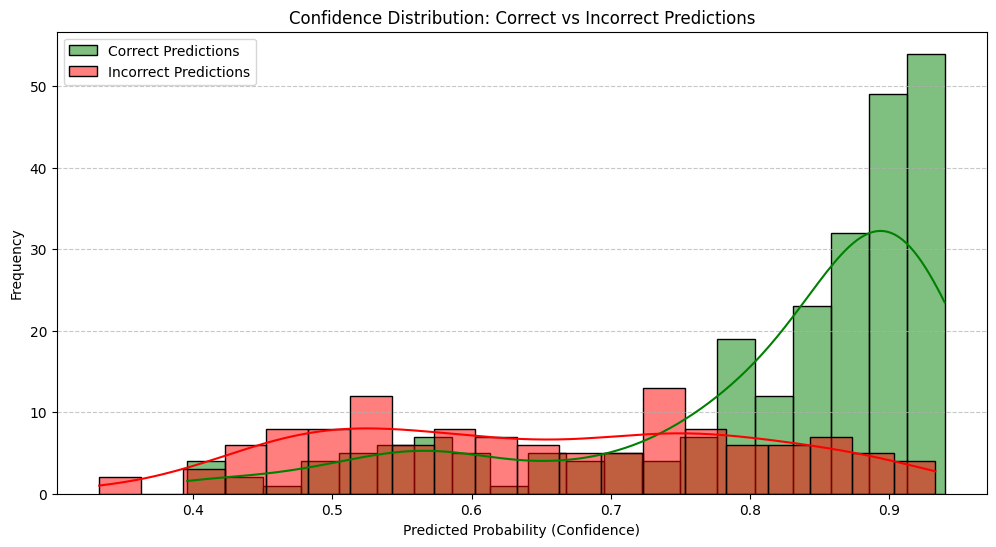

Average Confidence (Correct): 0.8134
Average Confidence (Incorrect): 0.6517


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from setfit import SetFitModel, Trainer, TrainingArguments

# 1. Train SetFit on a small subset for quick calibration check
sample_train = train.shuffle(seed=42).select(range(100))

model = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
trainer = Trainer(
    model=model,
    train_dataset=sample_train,
    eval_dataset=validation,
    column_mapping={"text": "text", "label": "label"}
)

trainer.train()

# 2. Predict samples and get probabilities
# predict_proba returns the probability for each class
probs_raw = model.predict_proba(validation['text'])

# Convert to numpy if it's a torch tensor
if torch.is_tensor(probs_raw):
    probs = probs_raw.cpu().numpy()
else:
    probs = probs_raw

preds = np.argmax(probs, axis=1)
true_labels = np.array(validation['label'])

# 3. Track correct/incorrect and their associated max probabilities (confidence)
correct_mask = (preds == true_labels)
confidences = np.max(probs, axis=1)

correct_probs = confidences[correct_mask]
incorrect_probs = confidences[~correct_mask]

# 4. Print 2 probability based distributions
plt.figure(figsize=(12, 6))

sns.histplot(correct_probs, color="green", label="Correct Predictions", kde=True, bins=20, alpha=0.5)
sns.histplot(incorrect_probs, color="red", label="Incorrect Predictions", kde=True, bins=20, alpha=0.5)

plt.title("Confidence Distribution: Correct vs Incorrect Predictions")
plt.xlabel("Predicted Probability (Confidence)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average Confidence (Correct): {np.mean(correct_probs):.4f}")
print(f"Average Confidence (Incorrect): {np.mean(incorrect_probs):.4f}")

Fitting CalibratedClassifierCV on training set...
Extracting full validation embeddings...


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


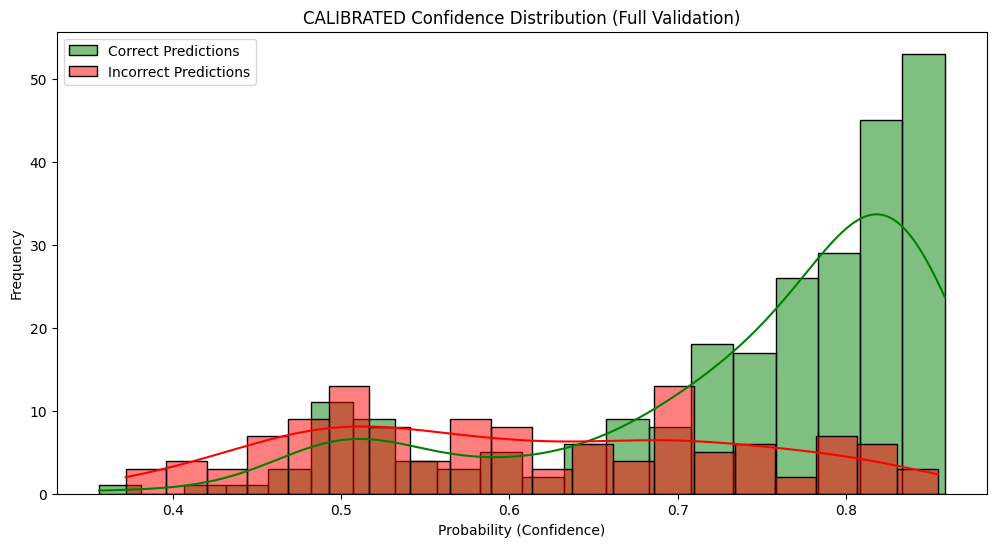

Average Calibrated Confidence (Correct): 0.7452
Average Calibrated Confidence (Incorrect): 0.6078


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
from sklearn.calibration import CalibratedClassifierCV
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Calibration Set
# Using full training set for calibration as requested
X_calib = model.model_body.encode(train['text'])
y_calib = np.array(train['label'])

# 2. Wrap and Refit the Classification Head
print("Fitting CalibratedClassifierCV on training set...")
calibrated_model = CalibratedClassifierCV(model.model_head, cv="prefit", method="sigmoid")
calibrated_model.fit(X_calib, y_calib)

# 3. Predict on Full Validation set with calibrated probabilities
print("Extracting full validation embeddings...")
X_val_full = model.model_body.encode(validation['text'])
y_val_full = np.array(validation['label'])

probs = calibrated_model.predict_proba(X_val_full)
preds = np.argmax(probs, axis=1)
confidences = np.max(probs, axis=1)

# 4. Visualize Distributions
correct_mask = (preds == y_val_full)
correct_probs = confidences[correct_mask]
incorrect_probs = confidences[~correct_mask]

plt.figure(figsize=(12, 6))
sns.histplot(correct_probs, color="green", label="Correct Predictions", kde=True, bins=20, alpha=0.5)
sns.histplot(incorrect_probs, color="red", label="Incorrect Predictions", kde=True, bins=20, alpha=0.5)
plt.title("CALIBRATED Confidence Distribution (Full Validation)")
plt.xlabel("Probability (Confidence)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(f"Average Calibrated Confidence (Correct): {np.mean(correct_probs):.4f}")
print(f"Average Calibrated Confidence (Incorrect): {np.mean(incorrect_probs):.4f}")

In [15]:
import umap
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 1. Prepare Embeddings
print("Extracting embeddings for train and validation...")
X_train_full = model.model_body.encode(train['text'])
y_train_full = np.array(train['label'])

print("Full length:", len(X_train_full))

X_val = model.model_body.encode(validation['text'])
y_val = np.array(validation['label'])

# 2. Create 100-sample stratified subset
_, X_train_100, _, y_train_100 = train_test_split(
    X_train_full, y_train_full, train_size=len(y_train_full)-100, stratify=y_train_full, random_state=42
)

# 3. Define Experiment Pipeline
def run_knn_experiment(X_tr, y_tr, X_v, y_v, name):
    print(f"\nRunning Experiment: {name}")

    # UMAP to 10 dimensions
    reducer = umap.UMAP(n_components=10, random_state=42)
    X_tr_reduced = reducer.fit_transform(X_tr)
    X_v_reduced = reducer.transform(X_v)

    # KNN Classifier
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_tr_reduced, y_tr)

    preds = knn.predict(X_v_reduced)
    acc = accuracy_score(y_v, preds)
    print(f"Accuracy ({name}): {acc:.4f}")
    return acc

# 4. Run Comparisons
acc_100 = run_knn_experiment(X_train_100, y_train_100, X_val, y_val, "100 Samples")
acc_full = run_knn_experiment(X_train_full, y_train_full, X_val, y_val, "Full Train")

print(f"\nSummary:\n100 Samples: {acc_100:.4f}\nFull Train: {acc_full:.4f}")

Extracting embeddings for train and validation...

Running Experiment: 100 Samples


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-

Accuracy (100 Samples): 0.6845

Running Experiment: Full Train


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Accuracy (Full Train): 0.6979

Summary:
100 Samples: 0.6845
Full Train: 0.6979


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


3257